In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# ----------------------------------------------------------------------
# Data Setup
# (Age, Miles ran per day)
# ----------------------------------------------------------------------

data_points = np.array([
    [25, 3],  # P1
    [40, 7],  # P2
    [30, 5]   # P3
])
points_labels = ['P1', 'P2', 'P3']

In [ ]:
# Definitions

def calculate_wcss(X, labels, centroids):
    """Calculates the Within-Cluster Sum of Squares (WCSS/Inertia)."""
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            distance_sq = np.sum((cluster_points - centroids[i]) ** 2)
            wcss += distance_sq
    return wcss

def manual_kmeans_k2(X):
    """
    Performs one full iteration of k-means for K=2, starting with
    P1 and P2 as initial centroids, and then calculates the final WCSS.
    """
    print("--- Manual K-Means (K=2) ---")
    # Initial Centroids (Step 0: Initialization)
    # Centroid A = P1 (25, 3), Centroid B = P2 (40, 7)
    mu_A = X[0].copy()
    mu_B = X[1].copy()
    centroids = np.array([mu_A, mu_B])

    print(f"Initial Centroids: Mu_A={mu_A}, Mu_B={mu_B}")
    
    # ------------------------------------------------------------------
    # Iteration 1: Assignment Step (Find C_i)
    # ------------------------------------------------------------------
    print("\n[Iteration 1: Assignment]")
    distances = cdist(X, centroids, 'sqeuclidean')
    labels = np.argmin(distances, axis=1) # 0 for Mu_A, 1 for Mu_B
    
    # P1: distance to Mu_A (0), to Mu_B (241) -> Cluster 0 (A)
    # P2: distance to Mu_A (241), to Mu_B (0) -> Cluster 1 (B)
    # P3: distance to Mu_A (29), to Mu_B (104) -> Cluster 0 (A)

    for i, label in enumerate(labels):
        print(f"{points_labels[i]} ({X[i]}): Assigned to Cluster {'A' if label == 0 else 'B'}")
        
    # ------------------------------------------------------------------
    # Iteration 1: Update Centroids (Find new Mu_i)
    # ------------------------------------------------------------------
    print("\n[Iteration 1: Update Centroids]")
    
    # Cluster A (Index 0): {P1, P3}
    C_A = X[labels == 0]
    new_mu_A = np.mean(C_A, axis=0) if len(C_A) > 0 else mu_A
    print(f"New Mu_A (Mean of P1, P3): {new_mu_A}")
    
    # Cluster B (Index 1): {P2}
    C_B = X[labels == 1]
    new_mu_B = np.mean(C_B, axis=0) if len(C_B) > 0 else mu_B
    print(f"New Mu_B (Mean of P2): {new_mu_B}")
    
    final_centroids = np.array([new_mu_A, new_mu_B])

    # ------------------------------------------------------------------
    # Iteration 2: Assignment Check (Convergence)
    # ------------------------------------------------------------------
    print("\n[Iteration 2: Convergence Check]")
    distances_new = cdist(X, final_centroids, 'sqeuclidean')
    new_labels = np.argmin(distances_new, axis=1)

    if np.array_equal(labels, new_labels):
        print("Assignments did not change (converged).")
    else:
        print("Assignments changed. Additional iterations needed.")

    # ------------------------------------------------------------------
    # 3. Final WCSS Calculation
    # ------------------------------------------------------------------
    final_wcss = calculate_wcss(X, labels, final_centroids)
    
    print("\n--- Final Results (Manual) ---")
    print(f"Final Centroids: {final_centroids}")
    print(f"Final Cluster Assignments: {labels}")
    print(f"3. Final Inertia (WCSS) for K=2: {final_wcss:.2f}")

    return labels, final_centroids, final_wcss

def plot_clusters(X, labels, centroids, title):
    """Plots the data points and the final cluster centroids."""
    plt.figure(figsize=(8, 6))
    
    # Define colors for the clusters
    colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

    # Plot data points
    for i in range(len(np.unique(labels))):
        cluster_data = X[labels == i]
        plt.scatter(
            cluster_data[:, 0], 
            cluster_data[:, 1], 
            s=150, 
            c=colors[i % len(colors)], 
            label=f'Cluster {i+1}', 
            alpha=0.6,
            edgecolors='w'
        )
        
    # Annotate the points (P1, P2, P3)
    for i, (x, y) in enumerate(X):
        plt.annotate(
            points_labels[i], 
            (x + 0.5, y - 0.2), # Offset label slightly
            fontsize=12, 
            fontweight='bold'
        )
        
    # Plot centroids
    plt.scatter(
        centroids[:, 0], 
        centroids[:, 1], 
        marker='*', 
        s=350, 
        c='black', 
        label='Centroids (Mean)', 
        edgecolors='white',
        linewidth=1.5
    )
    
    plt.title(title, fontsize=16)
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Miles Ran per Day', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    plt.show()



--- Manual K-Means (K=2) ---
Initial Centroids: Mu_A=[25  3], Mu_B=[40  7]

[Iteration 1: Assignment]
P1 ([25  3]): Assigned to Cluster A
P2 ([40  7]): Assigned to Cluster B
P3 ([30  5]): Assigned to Cluster A

[Iteration 1: Update Centroids]
New Mu_A (Mean of P1, P3): [27.5  4. ]
New Mu_B (Mean of P2): [40.  7.]

[Iteration 2: Convergence Check]
Assignments did not change (converged).

--- Final Results (Manual) ---
Final Centroids: [[27.5  4. ]
 [40.   7. ]]
Final Cluster Assignments: [0 1 0]
3. Final Inertia (WCSS) for K=2: 14.50


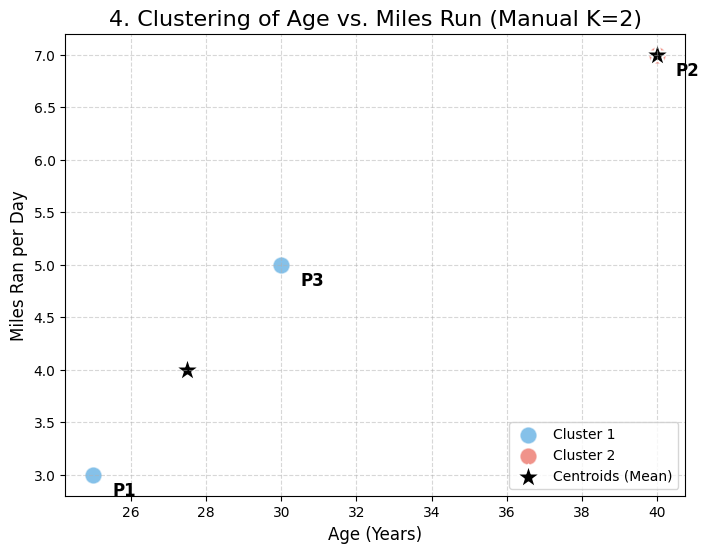

In [ ]:
manual_labels, manual_centroids, manual_wcss = manual_kmeans_k2(data_points)

plot_clusters(
    data_points, 
    manual_labels, 
    manual_centroids, 
    '4. Clustering of Age vs. Miles Run (Manual K=2)'
)

--- 5. Scikit-learn K-Means Comparison (K=2) ---
Scikit-learn converged successfully.
SKLEARN Final Centroids:
[[40.   7. ]
 [27.5  4. ]]
SKLEARN Final Cluster Assignments: [1 0 1]
SKLEARN Inertia (WCSS): 14.50

--- Comparison Summary ---
Manual WCSS: 14.50
Sklearn WCSS: 14.50
The WCSS values are identical, confirming the manual calculation.


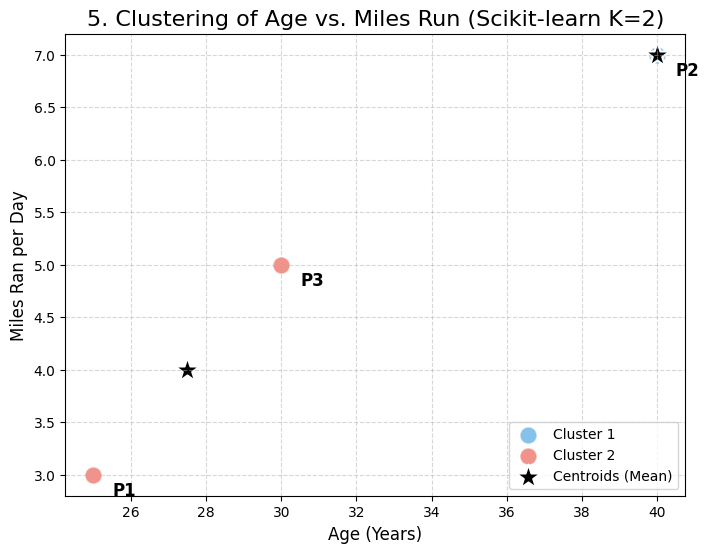

In [5]:
print("--- 5. Scikit-learn K-Means Comparison (K=2) ---")

# Initialize and fit the KMeans model
# Note: n_init='auto' is the recommended setting
kmeans_sklearn = KMeans(n_clusters=2, random_state=42, n_init='auto') 
kmeans_sklearn.fit(data_points)

# Extract results
sklearn_labels = kmeans_sklearn.labels_
sklearn_centroids = kmeans_sklearn.cluster_centers_
sklearn_inertia = kmeans_sklearn.inertia_

print("Scikit-learn converged successfully.")
print(f"SKLEARN Final Centroids:\n{sklearn_centroids}")
print(f"SKLEARN Final Cluster Assignments: {sklearn_labels}")
print(f"SKLEARN Inertia (WCSS): {sklearn_inertia:.2f}")


# Note on label order: The labels (0 and 1) might be swapped 
# between manual and sklearn runs due to random initialization, 
# but the clustering itself should be identical if the initialization 
# leads to the same global minimum (which it does here).

print("\n--- Comparison Summary ---")
print(f"Manual WCSS: {manual_wcss:.2f}")
print(f"Sklearn WCSS: {sklearn_inertia:.2f}")

if np.isclose(manual_wcss, sklearn_inertia):
    print("The WCSS values are identical, confirming the manual calculation.")
else:
    print("The WCSS values are different. Check manual steps.")
    
# Plot the sklearn results for visual confirmation
plot_clusters(
    data_points, 
    sklearn_labels, 
    sklearn_centroids, 
    '5. Clustering of Age vs. Miles Run (Scikit-learn K=2)'
)

# ----------------------------------------------------------------------
# 1. Elbow Method Calculation (Code support for analysis)
# ----------------------------------------------------------------------
# Now we calculate WCSS for K=1, 2, 3 to support the analysis in Section 1.



--- WCSS Values for Elbow Method ---
K=1: WCSS=124.67
K=2: WCSS=14.50
K=3: WCSS=0.00


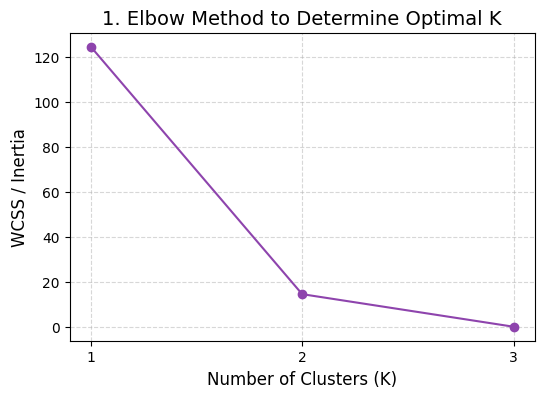

In [6]:
def calculate_elbow(X):
    wcss_list = []
    # Test k values from 1 to 3
    k_range = range(1, len(X) + 1)

    for k in k_range:
        if k == len(X): # WCSS is 0 when K=N
            wcss_list.append(0)
            continue
        
        # Use a stable random state for consistency
        kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans_model.fit(X)
        wcss_list.append(kmeans_model.inertia_)
    
    print("\n--- WCSS Values for Elbow Method ---")
    for k, wcss in zip(k_range, wcss_list):
        print(f"K={k}: WCSS={wcss:.2f}")

    # Plotting the elbow
    plt.figure(figsize=(6, 4))
    plt.plot(k_range, wcss_list, marker='o', linestyle='-', color='#8e44ad')
    plt.title('1. Elbow Method to Determine Optimal K', fontsize=14)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('WCSS / Inertia', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

calculate_elbow(data_points)
